In [76]:
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import sys
from pathlib import Path
import importlib
# add Modeling/ to Python path
project_root = Path.cwd().parents[2]
sys.path.append(str(project_root))
import Modeling
importlib.reload(Modeling)
from Modeling.models.plotting import animate_field_1d
import Modeling.models.beam_properties as beam_properties_module
importlib.reload(beam_properties_module)
PiezoBeamParams = beam_properties_module.PiezoBeamParams
from Modeling.models import FE_helpers 
importlib.reload(FE_helpers)
import matplotlib.pyplot as plt
# from Modeling.models.ROM import ROM
import Modeling.models.FE3 as FE_module
importlib.reload(FE_module)
FE = FE_module
# import Modeling.models.ROM as ROM_module
# importlib.reload(ROM_module)
# ROM = ROM_module.ROM

# from FE1 import PiezoBeamFE, frf_sweep, solve_newmark
import numpy as np
from numpy import pi	
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from IPython.display import clear_output
from matplotlib import cm, colors
import pandas as pd
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

In [77]:
e31/E_p
eps33/8.854e-12	

1671.5608764400272

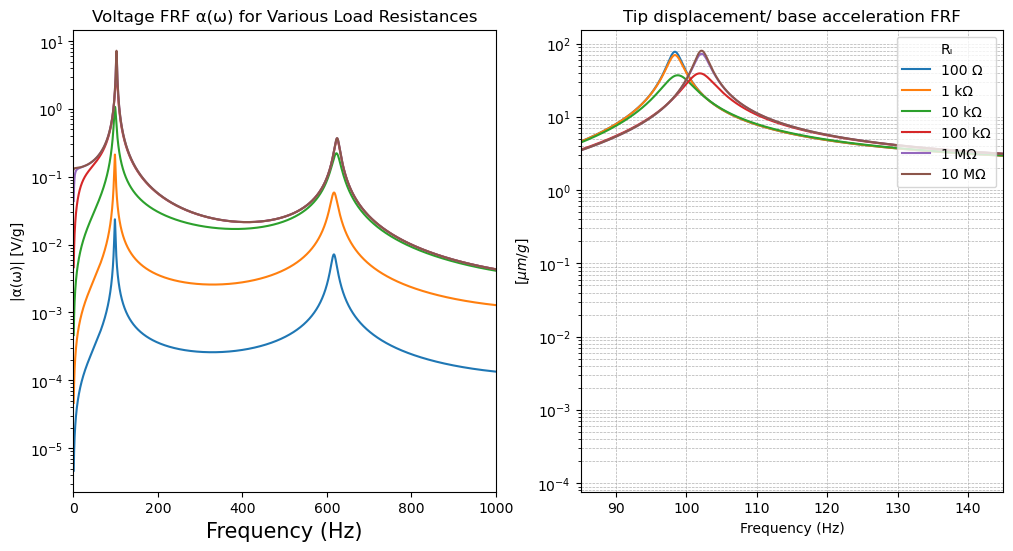

In [78]:
# %%
import numpy as np
from scipy.optimize import root_scalar, fsolve
from scipy.integrate import simpson as simps
conf = 'series'
# === Step 3: Define material+geo constants (Table 2.1) ===
# rho_p, rho_s = 7800, 8500          # [kg/m³]
# E_p, E_s   = 66e9, 100e9           # [Pa]
# e31, eps33 = -12.3, 14.8e-9        # [C/m²], [F/m]
# L, b       = 56e-3, 31.75e-3     # [m]
# hp, hs     = 0.267e-3, 0.127e-3    # [m]
# m = b*(rho_s * hs + 2 * rho_p * hp)
# M_t     = 0         # [kg]
# I_t = 0

# Etrurk=== Step 3: Define material+geo constants (Table 2.1) ===
# rho_p, rho_s = 7750, 2700          # [kg/m³]
# E_p, E_s   = 61e9, 70e9           # [Pa]
# e31, eps33 = -10.4, 13.3e-9        # [C/m²], [F/m]
# L, b       = 30e-3, 5e-3     # [m]
# hp, hs     = 0.15e-3, 0.05e-3    # [m]
# m = b*(rho_s * hs + 2 * rho_p * hp)
# I_t = 0  # kg·m², rotational inertia of the tip mass
# M_t     = 0         # [kg]
# Flexural rigidity YI via (3.10)
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import simpson as simps

class PiezoBeamFRF:
	def __init__(
		self, conf='series',
		rho_p=7800, rho_s=8500,
		E_p=66e9, E_s=100e9,
		e31=-12.3, eps33=14.8e-9,
		L=56e-3, b=31.75e-3,
		hp=0.267e-3, hs=0.127e-3,
		N_modes=4, zeta=0.01,
		M_t=0, I_t=0
	):
		self.conf = conf
		self.rho_p = rho_p
		self.rho_s = rho_s
		self.E_p = E_p
		self.E_s = E_s
		self.e31 = e31
		self.eps33 = eps33
		self.L = L
		self.b = b
		self.hp = hp
		self.hs = hs
		self.N_modes = N_modes
		self.zeta = zeta
		self.M_t = M_t
		self.I_t = I_t

		self.m = self.b * (self.rho_s * self.hs + 2 * self.rho_p * self.hp)
		self.hpc = (self.hp + self.hs)/2

		# Flexural rigidity
		term1 = self.E_s * self.hs**3 / 8
		term2 = self.E_p * ((self.hp + self.hs/2)**3 - self.hs**3/8)
		self.YI = 2 * self.b / 3 * (term1 + term2)

		self._compute_modes_and_shapes()
		self._compute_modal_properties()

	def eigen_eq(self, lam):
		t1 = 1 + np.cos(lam)*np.cosh(lam)
		t2 = lam*self.M_t/(self.m*self.L)*(np.cos(lam)*np.sinh(lam) - np.sin(lam)*np.cosh(lam))
		t3 = (lam**3 * self.I_t/ self.L**3 / self.m)*(np.cosh(lam)*np.sin(lam) + np.sinh(lam)*np.cos(lam))
		t4 = (lam**4 * self.M_t * self.I_t)/(self.m**2 * self.L**4)*(1 - np.cos(lam)*np.cosh(lam))
		return t1 + t2 - t3 + t4

	def _lambda_i(self, i):
		result = fsolve(self.eigen_eq, np.pi * (i + 0.5))
		return result[0]

	def _compute_modes_and_shapes(self):
		self.lambda_r = np.array([self._lambda_i(i) for i in range(self.N_modes)])
		self.omega_r = np.array([lam**2 * np.sqrt(self.YI/(self.m*self.L**4)) for lam in self.lambda_r])

		self.zeta_r = []
		for lam in self.lambda_r:
			num = (np.sin(lam) - np.sinh(lam)
				   + (self.M_t/(self.m*self.L))*(np.cos(lam)-np.cosh(lam)))
			den = (np.cos(lam) + np.cosh(lam)
				   - (self.M_t/(self.m*self.L))*(np.sin(lam)-np.sinh(lam)))
			self.zeta_r.append(num/den)
		self.zeta_r = np.array(self.zeta_r)

		self.xg = np.linspace(0, self.L, 500)
		self.A_r = []
		for i, lam in enumerate(self.lambda_r):
			phi_vals = self.phi_raw(self.xg, lam, self.zeta_r[i])
			dphiL = (lam/self.L) * (
				-np.sin(lam) - np.sinh(lam) + self.zeta_r[i] * (np.cos(lam) - np.cosh(lam))
			)
			I1 = self.m * simps(phi_vals**2, x =self.xg)
			I2 = self.M_t * (phi_vals[-1]**2)
			I3 = self.I_t * (dphiL**2)
			norm = I1 + I2 + I3
			self.A_r.append(1.0 / np.sqrt(norm))
		self.A_r = np.array(self.A_r)

	def phi_raw(self, x, lam, zr):
		arg = lam * x / self.L
		return (np.cos(arg) - np.cosh(arg)
				+ zr * (np.sin(arg) - np.sinh(arg)))

	def phi(self, r, x):
		return self.A_r[r] * self.phi_raw(x, self.lambda_r[r], self.zeta_r[r])

	def dphi_dx_at_L(self, r):
		lam, zr = self.lambda_r[r], self.zeta_r[r]
		arg = lam
		return self.A_r[r]*(lam/self.L)*(
			-np.sin(arg)-np.sinh(arg)
			+ zr*(np.cos(arg)-np.cosh(arg))
		)

	def _compute_modal_properties(self):
		self.sigma_r, self.tau_r = [], []
		for r in range(self.N_modes):
			ph = self.phi(r, self.xg)
			self.sigma_r.append(-self.m*simps(ph, x = self.xg) - self.M_t*self.phi(r, self.L))
			self.tau_r.append(-self.m*simps(self.xg*ph, x = self.xg) - self.M_t*self.L*self.phi(r, self.L))
		self.sigma_r = np.array(self.sigma_r)
		self.tau_r = np.array(self.tau_r)

		if self.conf == 'parallel':
			self.theta_r = 2*self.e31*self.b*self.hpc * np.array([self.dphi_dx_at_L(r) for r in range(self.N_modes)])
			self.C_p_eq  = 2*self.eps33*self.b*self.L/self.hp
		elif self.conf == 'series':
			self.theta_r = self.e31*self.b*self.hpc * np.array([self.dphi_dx_at_L(r) for r in range(self.N_modes)])
			self.C_p_eq  = self.eps33*self.b*self.L/self.hp/2
		else:
			raise ValueError('Invalid configuration: choose "series" or "parallel".')

	# FRFs and external interface methods
	def R_l(self, omega):
		return 1e3  # Default: 1kΩ; override as needed

	def FRF_alpha(self, omega, R_l=None):
		zeta = self.zeta
		if R_l is None:
			R_l = self.R_l
		den_mech = self.omega_r**2 - omega**2 + 1j*2*zeta*self.omega_r*omega
		num = np.sum(-1j*omega*self.theta_r*self.sigma_r / den_mech)
		den = (1/R_l(omega) + 1j*omega*self.C_p_eq
			   + np.sum(1j*omega*self.theta_r**2 / den_mech))
		return num/den

	def FRF_mu(self, omega, R_l=None):
		zeta = self.zeta
		if R_l is None:
			R_l = self.R_l
		den_mech = self.omega_r**2 - omega**2 + 1j*2*zeta*self.omega_r*omega
		num = np.sum(-1j*omega*self.theta_r*self.tau_r / den_mech)
		den = (1/R_l(omega) + 1j*omega*self.C_p_eq
			   + np.sum(1j*omega*self.theta_r**2 / den_mech))
		return num/den

	def FRF_beta(self, omega, x, R_l=None):
		zeta = self.zeta
		if R_l is None:
			R_l = self.R_l
		den_mech = self.omega_r**2 - omega**2 + 1j*2*zeta*self.omega_r*omega
		num_alpha = np.sum(1j*omega * self.theta_r * self.sigma_r / den_mech)
		den_elec  = (
			1.0/R_l(omega)
			+ 1j*omega*self.C_p_eq
			+ np.sum(1j*omega * self.theta_r**2 / den_mech)
		)
		alpha = num_alpha/den_elec
		s = 0+0j
		for r in range(self.N_modes):
			coeff = self.sigma_r[r]  - self.theta_r[r]*alpha
			s += coeff*self.phi(r, x)/den_mech[r]
		return s

	def FRF_trans(self, omega, x, R_l=None):
		return self.FRF_beta(omega, x, R_l)*omega**2

	def FRF_psi(self, omega, x, R_l=None):
		zeta = self.zeta
		if R_l is None:
			R_l = self.R_l
		den_mech = self.omega_r**2 - omega**2 + 1j*2*zeta*self.omega_r*omega
		den_elec = 1/R_l(omega) + 1j*omega*self.C_p_eq + np.sum(1j*omega*self.theta_r**2/den_mech)
		s = 0+0j
		for r in range(self.N_modes):
			denom = den_mech[r]
			coeff = (self.tau_r[r]
					 - self.theta_r[r]/den_elec*(1j*omega*self.theta_r[r]/denom))
			s += coeff*(1j*omega*self.theta_r[r]*self.tau_r[r]/denom)*self.phi(r, x)/denom
		return s
	

import matplotlib.pyplot as plt
# %matplotlib widget
# Frequency range: 1 Hz to 5000 Hz
frequencies = np.linspace(1, 1000, 10000)
omegas = 2 * np.pi * frequencies

# Load resistances and legend labels
R_l_list = [1e2, 1e3, 1e4, 1e5, 1e6, 1e7]
labels   = ['100 Ω', '1 kΩ', '10 kΩ', '100 kΩ', '1 MΩ', '10 MΩ']
beam = PiezoBeamFRF(conf='series')  # or 'parallel
fig, ax = plt.subplots(1,2,figsize=(12,6))

for Rl, lbl in zip(R_l_list, labels):
	# Temporarily override R_l(ω) to be constant = Rl
	def R_l(omega, Rl=Rl):
		return Rl
	# Compute α(ω) across the band
	alpha_vals = np.array([beam.FRF_alpha(w, R_l=R_l) for w in omegas])
	dyn_compl = np.array([beam.FRF_beta(w, L, R_l=R_l) for w in omegas])

	# Plot magnitude |α| (V/g) on log–log axes
	
	ax[0].set_xlabel('Frequency (Hz)', fontsize=15)
	# plt.ylim([1e-5, 1e2])
	ax[0].set_xlim([0, 1000])
	ax[0].set_title('Voltage FRF α(ω) for Various Load Resistances')
	ax[0].set_ylabel('|α(ω)| [V/g]')
	ax[0].semilogy(frequencies, np.abs(alpha_vals), linewidth=1.5, label=lbl)
	ax[1].set_xlim([85, 145])
	# plt.ylim([1e1, 1e3])
	ax[1].semilogy(frequencies, np.abs(dyn_compl*(frequencies*2*np.pi)**2), linewidth=1.5, label=lbl)
	ax[1].set_title('Tip displacement/ base acceleration FRF')
	ax[1].set_ylabel(r'$[\mu m/g]$')

ax[1].set_xlabel('Frequency (Hz)')


ax[1].legend(title='Rₗ', loc='upper right')
ax[1].grid(which='both', linestyle='--', linewidth=0.5)
# plt.tight_layout()
plt.show()



In [79]:
eps33/8.854e-12	

1671.5608764400272

In [81]:




params_fe = PiezoBeamParams(
    d31=-beam.e31/beam.E_p,        # Piezoelectric strain coefficient [m/V]
    eps_r=beam.eps33/8.854e-12	,           # Relative permittivity (dielectric constant)
    rho_p=beam.rho_p,        # Piezo density [kg/m³]
    rho_s=beam.rho_s,        # Substrate density [kg/m³]
    hp= beam.hp,        # Piezo thickness [m]
    hs= beam.hs,        # Substrate thickness [m]
    omega_p=2*np.pi*1,    # Lower frequency for Rayleigh damping [rad/s] (1 Hz)
    omega_q=2*np.pi*100   # Upper frequency for Rayleigh damping [rad/s] (100 Hz)
)
region_types = {
    'piezo': {'EI': beam.YI, 'rhoA': beam.m, 'h':20e-3},
}
region_sequence = ['piezo']
      
x_starts = np.array([0,]) * 1e-3
                    

geom = FE_module.build_geometry_from_types(beam.L, region_types, region_sequence, x_starts)
# Automatically detects piezos at indices 1 and 4

params_fe.geometry = geom

# ============================================================
# Build finite element model
# ============================================================
fe = FE_module.PiezoBeamFE(params_fe)

# ============================================================
# Multi-piezo excitation setup with phase control
# ============================================================
j_exc = []  # Indices of excited (actuator) piezos

# Time-domain simulation parameters
t_end = 100        # Simulation duration [s]
f0 = 50       # Starting frequency for chirp [Hz]
f1 = 200        # Ending frequency for chirp [Hz]
dt = 1/f1/20       # Time step (20 samples per highest frequency period) [s]

# Excitation amplitudes for each piezo [V]
A1, A2, A3 = 1, 15, 20

# Phase offsets for each piezo [rad]
phase1, phase2, phase3 = 0, np.pi/4, np.pi/2  # 0°, 45°, 90°

def v_exc(t):
    """
    Multi-piezo chirp excitation with phase offsets.
    Each piezo gets a frequency sweep with different amplitude and phase.
    
    Returns:
        array: Voltage for each excited piezo at time t
    """
    v0 = A1 * np.sin(2*np.pi*(f0 + t*(f1-f0)/t_end) * t + phase1)
    v1 = A2 * np.sin(2*np.pi*(f0 + t*(f1-f0)/t_end) * t + phase2)
    v2 = A3 * np.sin(2*np.pi*(f0 + t*(f1-f0)/t_end) * t + phase3)
    return np.array([v0])  # Single piezo excitation
    # return np.array([v0, v1, v2])  # Triple piezo excitation (uncomment for multi-piezo)

# Complex weights for frequency-domain analysis (amplitude * exp(i*phase))
phase_exc = np.array([phase1, phase2, phase3])
A_exc = np.array([A1, A2, A3])
weights_complex = A_exc * np.exp(1j * phase_exc)
A = 1e-6
# ============================================================
# Build ODE system with multi-piezo excitation
# ============================================================
ode = fe.build_ode_system_base_excitation(
    j_exc=j_exc,                           # Excited piezo indices
    u_base= lambda t: A * np.cos(2*np.pi*(f0 + t*(f1-f0)/t_end) * t ),    #base displacement excitation (optional, can be set to zero or a function)
    du_base= lambda t: -A * 2*np.pi*(f0 + 2*t*(f1-f0)/t_end) * np.sin(2*np.pi*(f0 + t*(f1-f0)/t_end) * t ), # base velocity (derivative of u_base)
    ddu_base= lambda t: -A *(2*np.pi*(f0 + 2*t*(f1-f0)/t_end)* 2*np.pi*(f0 + t*(f1-f0)/t_end) * t * np.cos(2*np.pi*(f0 + t*(f1-f0)/t_end) * t) + 4*np.pi*(f1-f0)/t_end*np.sin(2*np.pi*(f0 + t*(f1-f0)/t_end) * t)), # base acceleration (second derivative of u_base)
    R_c=1e3,                               # Circuit resistance [Ω]
    K_p=0.002,                              # Proportional feedback gain
    K_i=0.0,                             # Integral feedback gain
    K_c=0.0,                               # Cubic nonlinear gain (disabled)
    v_exc=v_exc                            # Time-domain excitation function
)

# ============================================================
# Frequency-domain FRF sweep
# ============================================================
f_fe = np.linspace(f0, f1, 500)                     # Frequency vector [Hz]
frf_fd = FE_helpers.frf_sweep(ode, f_fe*2*np.pi)   # Sweep (convert to rad/s)

# Extract frequency-domain results
N = ode.N_mech                                      # Number of mechanical DOFs
w_fd = frf_fd['u']                                  # Displacement FRF (complex)
w_dot_fd = frf_fd['u_dot']                          # Velocity FRF (complex)
freq_fd = frf_fd['freq']                            # Frequency vector [Hz]
vel_fd = np.mean(np.abs(w_dot_fd), axis=1)         # Spatially-averaged velocity magnitude

# ============================================================
# Time-domain simulation (Newmark-beta integration)
# ============================================================
# Initial conditions
ndof = ode.M.shape[0]                               # Total DOFs (mech + elec)
x0 = np.zeros(ndof)                                 # Zero initial displacement/charge
x_dot0 = np.zeros(ndof)                             # Zero initial velocity/voltage

# Run time integration
result = FE_helpers.solve_newmark(
	ode=ode,
	dt=dt,                                          # Time step [s]
	t_end=t_end,                                    # End time [s]
	beta=0.25,                                      # Newmark parameter (average acceleration)
	gamma=0.5,                                      # Newmark parameter (trapezoidal rule)
	newton_tol=1e-5,                                # Newton-Raphson convergence tolerance
	newton_maxiter=80,                               # Max Newton iterations per step
	x0=x0,
	x_dot0=x_dot0
)

# ============================================================
# Extract time-domain results
# ============================================================
t = result['t']                  # Time vector [s]
w = result['u']                  # Mechanical displacement [m]
w_dot = result['u_dot']          # Mechanical velocity [m/s]
w_ddot = result['u_ddot']        # Mechanical acceleration [m/s²]
q = result['q']                  # Electrical charge [C]
v = result['v']                  # Voltage [V]
spec_td = result['spectral']     # Time-domain FRF (FFT-based)



ValueError: operands could not be broadcast together with shapes (8,) (0,) 

In [88]:
fe.M_red.shape
print(fe.M[np.ix_(fe.free_dofs, [0])])
print(fe.M[:,0])

[[ 3.99646140e-04]
 [-1.79594068e-06]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 0.00000000e+00]]
[ 1.15453329e-03  3.03928423e-06  3.99646140e-04 -1.79594068e-06
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]


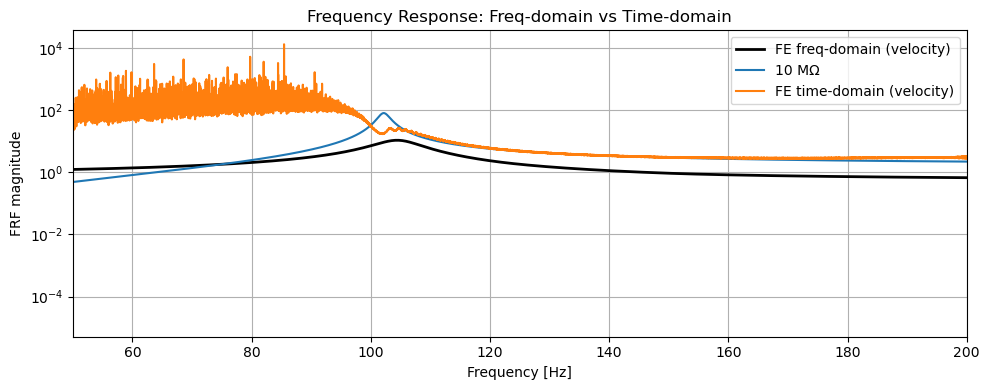

In [ ]:

# Time-domain FRF from FFT
freq_td = spec_td['freq']        # Frequency vector from FFT [Hz]
frf_td = spec_td['FRF']          # FRF magnitude (spatially averaged)

# ============================================================
# Plot FRF comparison (frequency vs time domain)
# ============================================================
plt.figure(figsize=(10, 4))
frf_td_y = np.mean(np.abs(spec_td['Y']), axis=1)

plt.semilogy(freq_fd, vel_fd/(1e-6*2*np.pi*freq_fd)
             , 'k-', lw=2, label='FE freq-domain (velocity)')
# plt.semilogy(frequencies, np.abs(alpha_vals), linewidth=1.5, label='ROM ')
plt.semilogy(frequencies, np.abs(dyn_compl*(frequencies*2*np.pi)**2), linewidth=1.5, label=lbl)
plt.semilogy(freq_td, frf_td*1e3, '-', label='FE time-domain (velocity)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('FRF magnitude')
plt.xlim([f0, f1])
plt.grid(True)
plt.legend()
plt.title('Frequency Response: Freq-domain vs Time-domain')
plt.tight_layout()
plt.show()

In [ ]:

fe.M[:, 0]

fe.M[np.ix_(fe.free_dofs, [0])]

np.ix_(fe.free_dofs, [0])


(array([[ 2],
        [ 3],
        [ 4],
        [ 5],
        [ 6],
        [ 7],
        [ 8],
        [ 9],
        [10],
        [11],
        [12],
        [13]]),
 array([[0]]))